# Lab 6 Experiment: Actor-Critic Multi-Seed Returns (Timestep Budget)

In [1]:
# Experiment controls -- change here, applies to all cells below
# TODO: Tune TOTAL_STEPS and NUM_SEEDS before the final run
SMOKE       = False
TOTAL_STEPS = 500        if SMOKE else 100_000
NUM_SEEDS   = 2          if SMOKE else 20

CFG = dict(
    actor_lr     = 1e-4,
    critic_lr    = 1e-3,
    gamma        = 0.99,
    hidden_sizes = (64, 64),
)

DATA_DIR = "../data/experiment"
IMG_DIR  = "../img/experiment"

print(f"SMOKE={SMOKE} | TOTAL_STEPS={TOTAL_STEPS:,} | NUM_SEEDS={NUM_SEEDS}")
print(f"CFG={CFG}")

SMOKE=False | TOTAL_STEPS=100,000 | NUM_SEEDS=20
CFG={'actor_lr': 0.0001, 'critic_lr': 0.001, 'gamma': 0.99, 'hidden_sizes': (64, 64)}


In [2]:
# TODO: Train Actor-Critic across NUM_SEEDS seeds for TOTAL_STEPS timesteps each.
# Outcome: per-seed CSVs in DATA_DIR; agent checkpoints saved per seed.
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, '..')

import os
import torch
import gymnasium as gym
import pandas as pd
from src.agent import Agent
from src.trainer import Trainer

os.makedirs(DATA_DIR, exist_ok=True)

env = gym.make("LunarLanderContinuous-v3")
obs_dim  = env.observation_space.shape[0]
act_dim  = env.action_space.shape[0]
act_low  = torch.tensor(env.action_space.low)
act_high = torch.tensor(env.action_space.high)

all_dfs = []

for seed in range(NUM_SEEDS):
    ckpt = f"{DATA_DIR}/seed{seed}_final.pt"
    if os.path.exists(ckpt):
        # reload CSV from disk to keep all_dfs consistent
        import glob
        matches = sorted(glob.glob(f"{DATA_DIR}/exp_s{seed}_*.csv"))
        if matches:
            df = pd.read_csv(matches[-1])
            all_dfs.append(df)
            print(f"Seed {seed}: on disk, skipping.")
            continue

    print(f"\n── Seed {seed} ──────────────────────────")
    torch.manual_seed(seed)
    agent = Agent(
        obs_dim=obs_dim, act_dim=act_dim,
        act_low=act_low, act_high=act_high,
        **CFG,
    )
    if seed == 0:
        print("Agent config:", agent._config)

    trainer = Trainer(agent, env, label=f"exp_s{seed}", seed=seed, checkpoint_path=ckpt)
    trainer.data_dir = DATA_DIR
    df = trainer.train_steps(total_steps=TOTAL_STEPS)
    all_dfs.append(df)

env.close()

total_steps_logged = sum(len(d) for d in all_dfs)
print(f"\nDone. Total steps logged: {total_steps_logged:,}")

Seed 0: on disk, skipping.

── Seed 1 ──────────────────────────


Training: 100%|██████████| 100000/100000 [01:00<00:00, 1651.59step/s, ep=245, return=0.2]  



── Seed 2 ──────────────────────────


Training: 100%|██████████| 100000/100000 [00:59<00:00, 1677.27step/s, ep=223, return=-53.6]



── Seed 3 ──────────────────────────


...


── Seed 18 ──────────────────────────


Training: 100%|██████████| 100000/100000 [00:59<00:00, 1671.96step/s, ep=198, return=29.4] 



── Seed 19 ──────────────────────────


Training: 100%|██████████| 100000/100000 [01:00<00:00, 1649.50step/s, ep=217, return=-19.4]



Done. Total steps logged: 2,000,000


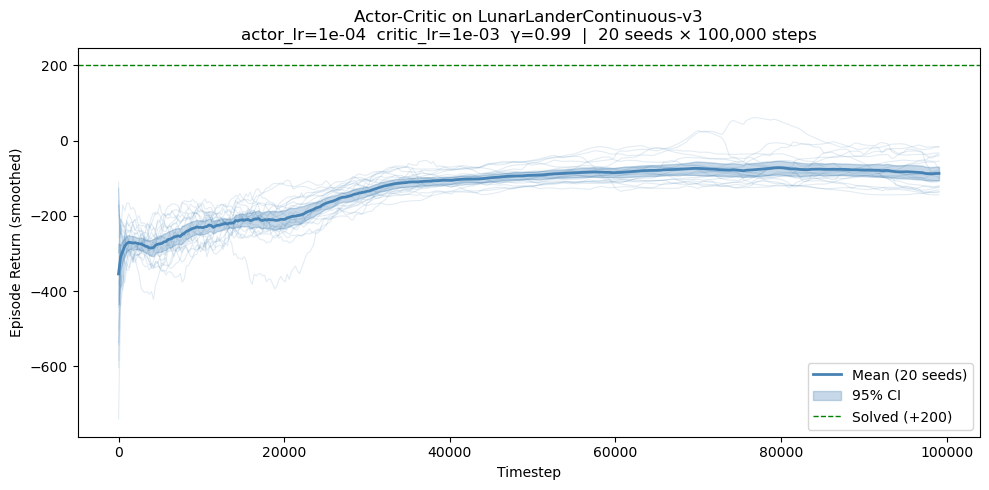

Saved: ../img/experiment/return_vs_timesteps.png


In [3]:
# TODO: Plot return vs. timestep across all seeds (mean +/- 95% CI).
# Outcome: learning curve saved to IMG_DIR/return_vs_timesteps.png
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

os.makedirs(IMG_DIR, exist_ok=True)

df_all = pd.concat(all_dfs, ignore_index=True)
seed_labels = df_all["label"].unique()

# build one smoothed curve per seed interpolated onto a common timestep grid
def smooth(values, window=50):
    out = np.full_like(values, np.nan, dtype=float)
    for i in range(len(values)):
        start = max(0, i - window + 1)
        out[i] = np.mean(values[start:i+1])
    return out

# episode-level return keyed by global_step of the first step in each episode
ep_curves = []
for label in seed_labels:
    s_df = df_all[df_all["label"] == label]
    ep_summary = (
        s_df.groupby("episode")
        .agg(ep_return=("episode_return", "first"),
             first_step=("global_step", "min"))
        .reset_index()
        .sort_values("first_step")
    )
    ep_curves.append((ep_summary["first_step"].values,
                      ep_summary["ep_return"].values))

max_ts = min(c[0][-1] for c in ep_curves)
grid   = np.linspace(0, max_ts, 400)

interpolated = []
for ts, rets in ep_curves:
    smoothed = smooth(rets, window=20)
    valid = ~np.isnan(smoothed)
    interpolated.append(np.interp(grid, ts[valid].astype(float), smoothed[valid]))

mat  = np.array(interpolated)
mean = mat.mean(axis=0)
se   = mat.std(axis=0) / np.sqrt(len(mat))
ci95 = 1.96 * se

fig, ax = plt.subplots(figsize=(10, 5))
for row in mat:
    ax.plot(grid, row, alpha=0.15, color="steelblue", linewidth=0.8)
ax.plot(grid, mean, color="steelblue", linewidth=2, label=f"Mean ({len(seed_labels)} seeds)")
ax.fill_between(grid, mean - ci95, mean + ci95, color="steelblue", alpha=0.3, label="95% CI")
ax.axhline(200, color="green", linestyle="--", linewidth=1, label="Solved (+200)")
ax.set_xlabel("Timestep")
ax.set_ylabel("Episode Return (smoothed)")
ax.set_title(
    f"Actor-Critic on LunarLanderContinuous-v3\n"
    f"actor_lr={CFG['actor_lr']:.0e}  critic_lr={CFG['critic_lr']:.0e}  "
    f"γ={CFG['gamma']}  |  {len(seed_labels)} seeds × {TOTAL_STEPS:,} steps"
)
ax.legend(loc="lower right")
plt.tight_layout()
out_path = f"{IMG_DIR}/return_vs_timesteps.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

In [5]:
# TODO: Print summary table row for comparison with W8.
# Outcome: key stats from this run formatted to match the W8 summary table.
# DONE
import numpy as np
import pandas as pd

df_all = pd.concat(all_dfs, ignore_index=True)
seed_labels = df_all["label"].unique()

# one mean-return per seed (mean over all episodes, matching W8 aggregation)
seed_means = []
for label in seed_labels:
    s_df = df_all[df_all["label"] == label]
    ep_returns = s_df.groupby("episode")["episode_return"].first().values
    seed_means.append(ep_returns.mean())

seed_means = np.array(seed_means)

label = f"Actor-Critic (actor_lr={CFG['actor_lr']:.0e}, critic_lr={CFG['critic_lr']:.0e})"
header = f"{'Configuration':<55} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}"
sep    = "-" * len(header)
row    = (
    f"{label:<55} "
    f"{seed_means.mean():>8.1f} "
    f"{seed_means.std():>8.1f} "
    f"{seed_means.min():>8.1f} "
    f"{seed_means.max():>8.1f}"
)
print(header)
print(sep)
print(row)

Configuration                                               Mean      Std      Min      Max
-------------------------------------------------------------------------------------------
Actor-Critic (actor_lr=1e-04, critic_lr=1e-03)            -170.4     19.2   -213.1   -132.9
